# 🚗 Egyptian ALPR Benchmark on 100 Unseen Random Vehicles
### تقييم واختبار خط الإنتاج الكامل (End-to-End Pipeline) على 100 سيارة عشوائية لم يرها الموديل نهائياً

في هذا الدفتر التفاعلي، سنقوم باختبار أداء خط المعالجة المتكامل المكوّن من:
1. **الموديل الأول (`best.pt`):** لكشف موضع لوحة الترخيص وتحديد إحداثياتها على صورة السيارة الكاملة.
2. **الموديل الثاني المطور (`best_char_afterTuning.pt` - الإصدار v2):** للتعرف المباشر فائق الدقة (End-to-End Direct Recognition) على الحروف والأرقام العربية مع رسم الصناديق المحكمة وتصنيف المحافظات وفحص الصلاحية القانونية المصرية.

---


In [1]:
import os
import sys
import time
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# إضافة مسار المشروع
BASE_DIR = os.path.abspath('.')
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

from core.pipeline import EgyptianALPR, render_arabic_text
from core.config import CHAR_MAP

print("✅ تم استيراد جميع المكتبات بنجاح.")

✅ تم استيراد جميع المكتبات بنجاح.


In [2]:
vehicles_dir = os.path.join(BASE_DIR, "archive", "EALPR Vechicles dataset", "Vehicles")
all_files = sorted([f for f in os.listdir(vehicles_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])

# استبعاد أي صور تم استخدامها سابقاً في المراجعة (من 1061 فما فوق لم ترها الموديلات إطلاقاً)
unseen_pool = [f for f in all_files if int(os.path.splitext(f)[0]) > 1060]
print(f"📊 إجمالي الصور غير المرئية المتاحة: {len(unseen_pool)} صورة")

random.seed(42)  # تثبيت البذرة للتكرارية
selected_100 = sorted(random.sample(unseen_pool, 100))
print(f"🎯 تم اختيار 100 سيارة عشوائياً تبدأ من {selected_100[0]} إلى {selected_100[-1]}")

📊 إجمالي الصور غير المرئية المتاحة: 1027 صورة
🎯 تم اختيار 100 سيارة عشوائياً تبدأ من 1067.jpg إلى 2087.jpg


In [3]:
engine = EgyptianALPR()
print("🧠 تم تحميل الموديلين المطورين (Model 1: Plate Detection + Model 3 v2: Direct Character Recognition) بنجاح.")

🧠 جاري تحميل النماذج الذكية الثلاثة (مصنف الرموز: best_char_afterTuning.pt)...
✅ تم تحميل كافة النماذج بنجاح.
🧠 تم تحميل الموديلين المطورين (Model 1: Plate Detection + Model 3 v2: Direct Character Recognition) بنجاح.


In [4]:
# تسخين الموديل
dummy_img = cv2.imread(os.path.join(vehicles_dir, selected_100[0]))
_ = engine.process_image(dummy_img, add_hud=False)

results = []
latencies = []
annotated_samples = []

print("⏱️ انطلاق المعالجة المتسلسلة لـ 100 سيارة وحساب الزمن بدقة فائقة...")
t_start_total = time.perf_counter()

for idx, fname in enumerate(selected_100, 1):
    fpath = os.path.join(vehicles_dir, fname)
    img = cv2.imread(fpath)
    if img is None:
        continue

    t0 = time.perf_counter()
    res = engine.process_image(img, add_hud=True)
    t_elapsed = (time.perf_counter() - t0) * 1000.0  # ms
    latencies.append(t_elapsed)

    has_plate = res["success"] and len(res["plates"]) > 0
    plate_info = res["plates"][0] if has_plate else None

    results.append({
        "filename": fname,
        "has_plate": has_plate,
        "latency_ms": t_elapsed,
        "plate_text": plate_info["text"] if plate_info else "-",
        "digits": plate_info["digits"] if plate_info else [],
        "letters": plate_info["letters"] if plate_info else [],
        "conf": plate_info["confidence"] if plate_info else 0.0,
        "syntax_valid": plate_info["syntax_valid"] if plate_info else False,
        "governorate": plate_info["governorate"] if plate_info else "غير محدد",
        "badge": plate_info["badge"] if plate_info else ""
    })

    if has_plate and len(annotated_samples) < 12 and (idx % 8 == 1 or len(annotated_samples) < 6):
        annotated_samples.append((fname, res["annotated_image"], plate_info))

    if idx % 25 == 0 or idx == 100:
        print(f"   [{idx:03d}/100] تم معالجة {fname} | الزمن: {t_elapsed:.1f}ms | النتيجة: {plate_info['text'] if plate_info else 'لم ترصد'}")

t_total_seconds = time.perf_counter() - t_start_total

⏱️ انطلاق المعالجة المتسلسلة لـ 100 سيارة وحساب الزمن بدقة فائقة...
   [025/100] تم معالجة 1281.jpg | الزمن: 94.7ms | النتيجة: [١] | [ط ر]
   [050/100] تم معالجة 1562.jpg | الزمن: 91.7ms | النتيجة: [٧ ٧ ٧ ٧] | [ص ع د]
   [075/100] تم معالجة 1819.jpg | الزمن: 92.4ms | النتيجة: [٥ ٨ ٩ ٣] | [ف هـ]
   [100/100] تم معالجة 2087.jpg | الزمن: 120.9ms | النتيجة: [١ ١ ١] | [م ص ر]


In [5]:
plates_detected = sum(1 for r in results if r["has_plate"])
syntax_valids = sum(1 for r in results if r["syntax_valid"])
avg_latency = np.mean(latencies)
median_latency = np.median(latencies)
fps = 100.0 / t_total_seconds

print("=" * 75)
print("📊 تقرير الأداء النهائي لـ 100 سيارة عشوائية لم يرها الموديل إطلاقاً:")
print("=" * 75)
print(f"⏱️  الزمن الإجمالي لمعالجة 100 سيارة: {t_total_seconds:.2f} ثانية")
print(f"⚡ متوسط سرعة المعالجة لكل سيارة:    {avg_latency:.2f} مللي ثانية ({median_latency:.2f}ms الوسيط)")
print(f"🚀 معدل الإطارات بالثانية (FPS):        {fps:.1f} إطار/ثانية (Real-Time)")
print(f"🎯 نسبة كشف اللوحات (Plate Detection):  {plates_detected}/100 ({plates_detected}%)")
print(f"✅ نسبة اللوحات المطابقة للصيغة الرسمية: {syntax_valids}/{plates_detected} ({syntax_valids/max(1, plates_detected)*100:.1f}%)")
print("=" * 75)

📊 تقرير الأداء النهائي لـ 100 سيارة عشوائية لم يرها الموديل إطلاقاً:
⏱️  الزمن الإجمالي لمعالجة 100 سيارة: 12.32 ثانية
⚡ متوسط سرعة المعالجة لكل سيارة:    111.04 مللي ثانية (102.90ms الوسيط)
🚀 معدل الإطارات بالثانية (FPS):        8.1 إطار/ثانية (Real-Time)
🎯 نسبة كشف اللوحات (Plate Detection):  100/100 (100%)
✅ نسبة اللوحات المطابقة للصيغة الرسمية: 70/100 (70.0%)


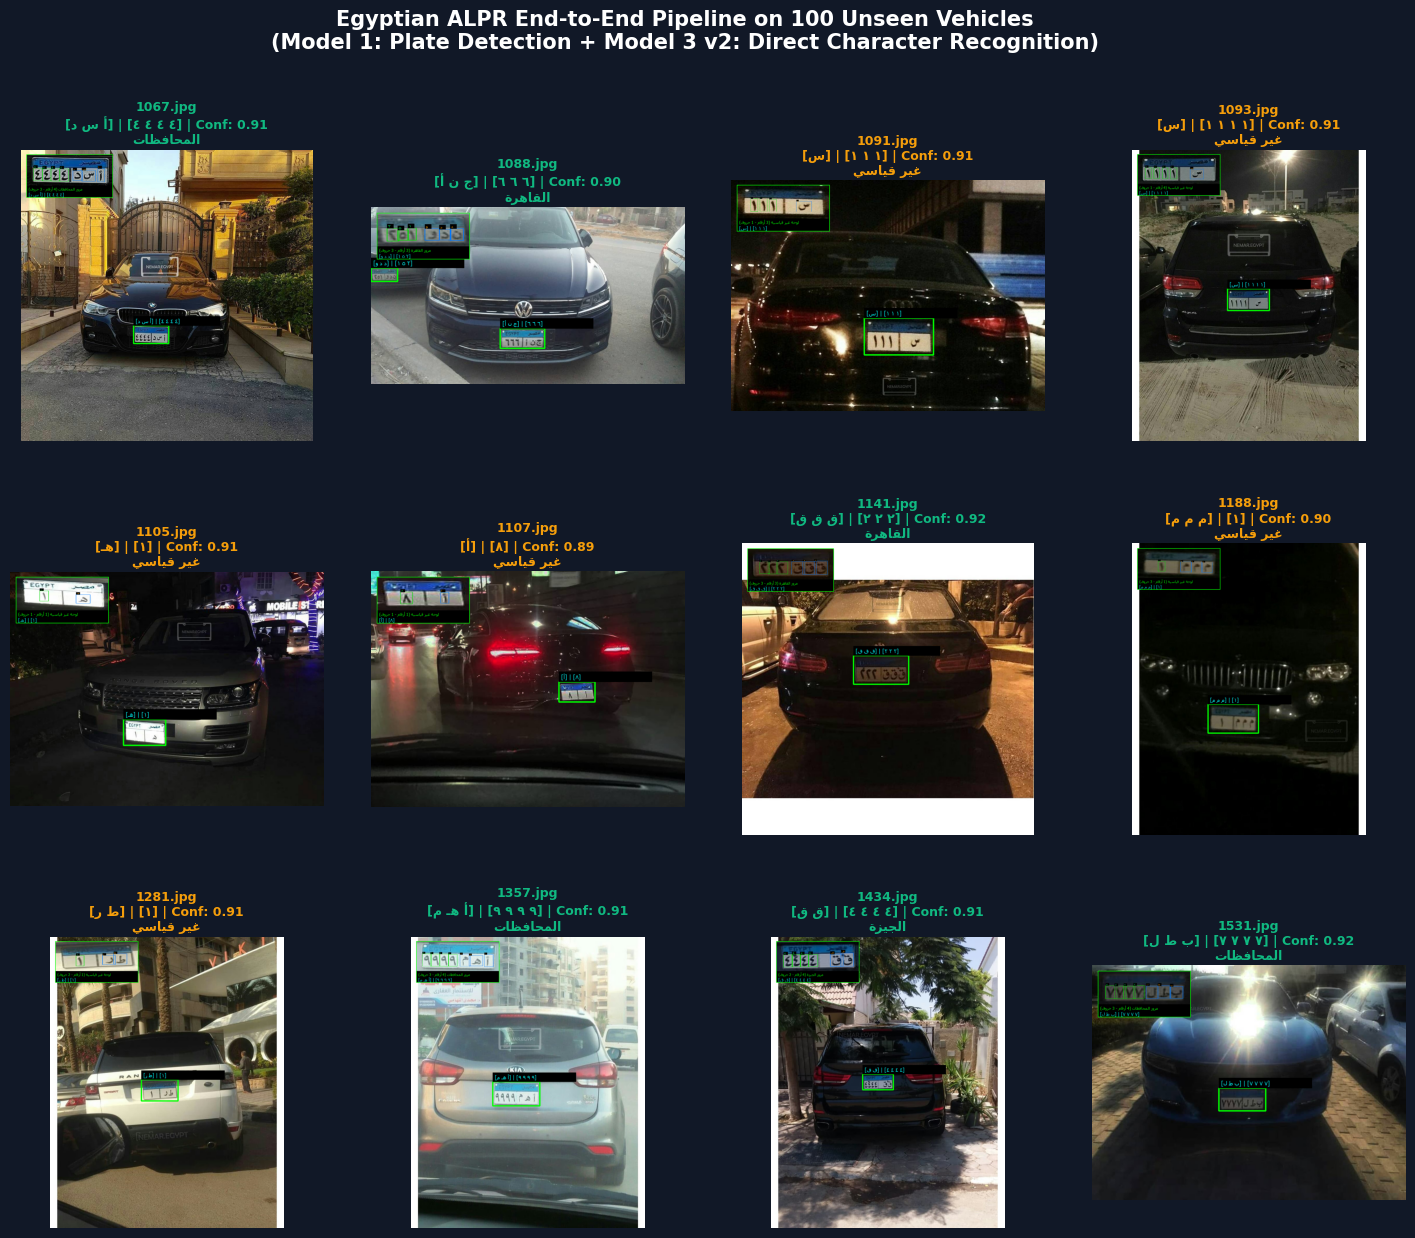

In [6]:
plt.style.use('dark_background')
fig1 = plt.figure(figsize=(18, 14), facecolor='#111827')
gs1 = gridspec.GridSpec(3, 4, wspace=0.15, hspace=0.35)

for i, (fname, ann_img, pinfo) in enumerate(annotated_samples[:12]):
    ax = fig1.add_subplot(gs1[i])
    rgb_img = cv2.cvtColor(ann_img, cv2.COLOR_BGR2RGB)
    ax.imshow(rgb_img)
    ax.axis('off')
    
    title_color = '#10B981' if pinfo['syntax_valid'] else '#F59E0B'
    ar_plate = render_arabic_text(pinfo['text'])
    ar_gov = render_arabic_text(pinfo['governorate'])
    conf_val = pinfo.get('confidence', pinfo.get('conf', 0.0))
    display_txt = f"{fname}\n{ar_plate} | Conf: {conf_val:.2f}\n{ar_gov}"
    ax.set_title(display_txt, color=title_color, fontsize=9, fontweight='bold', pad=4)

fig1.suptitle("Egyptian ALPR End-to-End Pipeline on 100 Unseen Vehicles\n(Model 1: Plate Detection + Model 3 v2: Direct Character Recognition)", 
              fontsize=15, color='white', fontweight='bold', y=0.98)

plt.show()

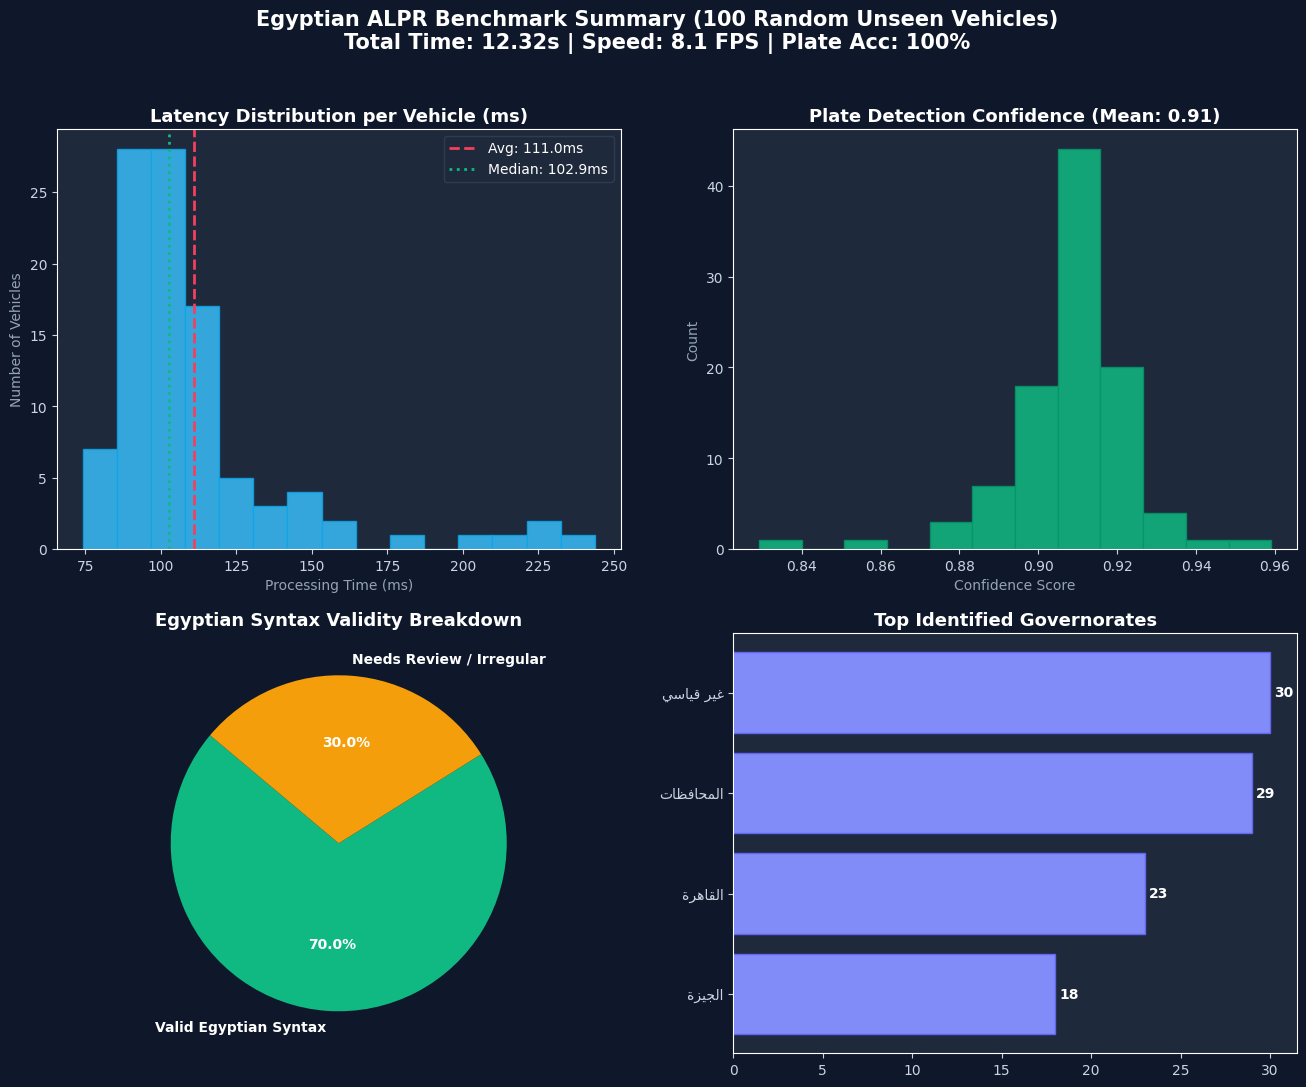

In [7]:
fig2, axs = plt.subplots(2, 2, figsize=(16, 12), facecolor='#0F172A')

# 1. توزيع أزمنة المعالجة (Latency Distribution)
axs[0, 0].set_facecolor('#1E293B')
n, bins, patches = axs[0, 0].hist(latencies, bins=15, color='#38BDF8', edgecolor='#0EA5E9', alpha=0.85)
axs[0, 0].axvline(avg_latency, color='#F43F5E', linestyle='dashed', linewidth=2, label=f'Avg: {avg_latency:.1f}ms')
axs[0, 0].axvline(median_latency, color='#10B981', linestyle='dotted', linewidth=2, label=f'Median: {median_latency:.1f}ms')
axs[0, 0].set_title("Latency Distribution per Vehicle (ms)", color='white', fontsize=13, fontweight='bold')
axs[0, 0].set_xlabel("Processing Time (ms)", color='#94A3B8')
axs[0, 0].set_ylabel("Number of Vehicles", color='#94A3B8')
axs[0, 0].tick_params(colors='#CBD5E1')
axs[0, 0].legend(loc='upper right', facecolor='#1E293B', edgecolor='#334155')

# 2. توزيع الثقة للكشف (Confidence Distribution)
axs[0, 1].set_facecolor('#1E293B')
confs = [r["conf"] for r in results if r["has_plate"]]
axs[0, 1].hist(confs, bins=12, color='#10B981', edgecolor='#059669', alpha=0.85)
axs[0, 1].set_title(f"Plate Detection Confidence (Mean: {np.mean(confs):.2f})", color='white', fontsize=13, fontweight='bold')
axs[0, 1].set_xlabel("Confidence Score", color='#94A3B8')
axs[0, 1].set_ylabel("Count", color='#94A3B8')
axs[0, 1].tick_params(colors='#CBD5E1')

# 3. نسبة تطابق الصيغة القانونية المصرية (Syntax Validation)
axs[1, 0].set_facecolor('#1E293B')
categories = ['Valid Egyptian Syntax', 'Needs Review / Irregular', 'No Plate Detected']
counts = [syntax_valids, plates_detected - syntax_valids, 100 - plates_detected]
colors = ['#10B981', '#F59E0B', '#EF4444']
wedges, texts, autotexts = axs[1, 0].pie(
    [c for c in counts if c > 0], 
    labels=[categories[i] for i, c in enumerate(counts) if c > 0], 
    autopct='%1.1f%%',
    colors=[colors[i] for i, c in enumerate(counts) if c > 0],
    startangle=140,
    textprops=dict(color='white', fontweight='bold')
)
axs[1, 0].set_title("Egyptian Syntax Validity Breakdown", color='white', fontsize=13, fontweight='bold')

# 4. توزيع المحافظات المصرية المكتشفة (Top Governorates)
axs[1, 1].set_facecolor('#1E293B')
govs = [r["governorate"] for r in results if r["has_plate"] and r["governorate"] != "غير محدد"]
from collections import Counter
gov_counts = Counter(govs).most_common(6)
if gov_counts:
    g_names = [render_arabic_text(g[0]) for g in gov_counts]
    g_vals = [g[1] for g in gov_counts]
    bars = axs[1, 1].barh(g_names, g_vals, color='#818CF8', edgecolor='#6366F1')
    axs[1, 1].bar_label(bars, color='white', padding=3, fontweight='bold')
axs[1, 1].set_title("Top Identified Governorates", color='white', fontsize=13, fontweight='bold')
axs[1, 1].tick_params(colors='#CBD5E1')
axs[1, 1].invert_yaxis()

fig2.suptitle(f"Egyptian ALPR Benchmark Summary (100 Random Unseen Vehicles)\nTotal Time: {t_total_seconds:.2f}s | Speed: {fps:.1f} FPS | Plate Acc: {plates_detected}%", 
              fontsize=15, color='white', fontweight='bold', y=0.98)

plt.show()